In [1]:
import warnings
warnings.filterwarnings("ignore")
import pickle
import mne
import neurokit2 as nk2
import time
import math
import glob, sys, os 
import numpy as np
import scipy as sp
from scipy.stats import shapiro
import seaborn as sns
import re
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.colors as mcolors
import joblib
import fooof as fooof
from fooof import FOOOF
import ordpy 
import logging
from scipy.stats import pearsonr, ttest_ind
import itertools
from statannotations.Annotator import Annotator

from scipy.stats import mannwhitneyu

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from scipy.stats import shapiro
from scipy.stats import levene
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.metrics import make_scorer, accuracy_score
from sklearn.metrics import roc_curve, auc

logging.getLogger('mne').setLevel(logging.WARNING)
pd.set_option('display.max_rows', 500)

# Get Info 

In [2]:
# Load demographics + bx data 
in_dir = '/Users/derek/Documents/PICU/Manuscript_analysis/'
output_dir = f'{in_dir}/Manuscript Redo/Figures/'

metric_o_i = ['SampEn','PEn','CWPEn','LZC_PSN', 'LZC', 'LE','HiguchiFD','dfa','dfaDelta','dfaTheta','dfaAlpha',
              'FOOOF_Offset','FOOOF_Slope', '|delta|Power', 'delta_RelPower','|theta|Power','theta_RelPower','|alpha|Power',
              'alpha_RelPower', '|beta|Power', 'beta_RelPower', '|low-gamma|Power', 'low-gamma_RelPower']

metric_interested = ['SampEn','PEn','CWPEn','LZC','LE','HiguchiFD', 'dfaAlpha', 'FOOOF_Offset', 'FOOOF_Slope', '|delta|Power', '|theta|Power','|alpha|Power', '|beta|Power', '|low-gamma|Power',]

# Define metric_names dictionary for proper naming
metric_names = {
    "SampEn": "Sample Entropy",
    "PEn": "Permutation Entropy",
    "CWPEn": "Conditional Weighted Permutation Entropy",
    "LZC_PSN": "Lempel-Ziv Complexity-Phase Shuffled",
    "LZC": "Lempel-Ziv Complexity",
    "LE": "Lyapunov Exponent",
    "HiguchiFD": "Higuchi Fractal Dimension",
    "dfa": "Detrended Fluctuation Analysis",
    "dfaDelta": "Detrended Fluctuation Analysis Delta",
    "dfaTheta": "Detrended Fluctuation Analysis Theta",
    "dfaAlpha": "Detrended Fluctuation Analysis Alpha",
    "FOOOF_Offset": "Spectral Slope Offset",
    "FOOOF_Slope": "Spectral Slope",
    "|delta|Power": "Absolute Delta Power",
    "delta_RelPower": "Delta Relative Power",
    "|theta|Power": "Absolute Theta Power",
    "theta_RelPower": "Relative Theta Power",
    "|alpha|Power": "Absolute Alpha Power",
    "alpha_RelPower": "Relative Alpha Power",
    "|beta|Power": "Absolute Beta Power",
    "beta_RelPower": "Relative Beta Power",
    "|low-gamma|Power": "Absolute Gamma Power",
    "low-gamma_RelPower": "Relative Gamma Power",
}

# Define metrics of interest
metric_interested = ['SampEn', 'PEn', 'CWPEn', 'LZC', 'LE', 'HiguchiFD', 'dfaAlpha', 'FOOOF_Offset', 'FOOOF_Slope', '|delta|Power', '|theta|Power', '|alpha|Power', '|beta|Power', '|low-gamma|Power']

def extract_participant_id(file):
    return file[:9]
    
#vis_dem = pd.read_csv("/Users/derek/Documents/PICU/Manuscript_analysis/Visual_df.csv")
demo_csv = f'{in_dir}/PICU_DEMO_Clean.csv'
demos = pd.read_csv(demo_csv)
demos = demos.drop(['Unnamed: 16','Unnamed: 17'], axis=1)
demos = demos.drop([41])
filtered_data_age = demos[demos['age_years'] <= 5][['participant_id']]
filtered_data_gose = demos[demos['GOSE_3mo'].isna() | (demos['GOSE_3mo'] == '') | ~np.isfinite(demos['GOSE_3mo'])][['participant_id']]
filtered_data_age_gose = demos[
    (demos['age_years'] >= 5) & 
    (demos['GOSE_3mo'].notna()) & 
    (demos['GOSE_3mo'] != '')]

print(f"# Old Metrics {len(metric_o_i)}, # New Metrics {len(metric_interested)}")
ordered_file = f"{in_dir}/all_temporal_order.csv"
ordered_files_csv = pd.read_csv(ordered_file)
output_filename = f"{in_dir}/all_data_name.pkl"

print(f"Data retrieved from {output_filename}")
with open(output_filename, 'rb') as input_file:
    all_data_name_loaded = pickle.load(input_file)

orig_keys_all_files = all_data_name_loaded.keys()

base_files = []
for i in orig_keys_all_files:
    if "ase" in i:
        base_files.append(i)
for i in orig_keys_all_files:
    filename = i
    if "HM" in filename and not any(substring in filename for substring in ["ro", "id", "ex"]):
        base_files.append(filename)
for i in orig_keys_all_files:
    filename = i
    if "ent" in filename and not any(substring in filename for substring in ["ro", "id", "ex"]):
        base_files.append(filename)
for i in orig_keys_all_files:
    filename = i
    if "orphine" in filename and not any(substring in filename for substring in ["ro", "id", "ex"]):
        base_files.append(filename)
        
sed_files = []
for i in orig_keys_all_files:
    filename = i
    if filename not in base_files:
        if "Ket" not in filename:
            sed_files.append(filename)
prop_files = []
for i in sed_files:
    filename = i
    if "rop" in filename and not any(substring in filename for substring in ["id", "ex"]):
        prop_files.append(filename)
mid_files = []
for i in sed_files:
    filename = i
    if "id" in filename and not any(substring in filename for substring in ["rop", "ex"]):
        mid_files.append(filename)
dex_mix_files = []
for i in sed_files:
    filename = i
    if filename not in prop_files:
        if filename not in mid_files:
            dex_mix_files.append(filename)

# naming is off, is rop, for the processed files to have drop added in changes my naming and how i searched through 
# total ordered files listed from raw is 393
print("All files: ", len(orig_keys_all_files)) # all data is 366
print("Base files: ",len(base_files)) # 82 files = baselines, fent only nad HM only, Morphine
print("Sed files: ",len(sed_files)) # Sed is 266 without the ketamine (18 files)
print("Prop files: ",len(prop_files)) # 56 propofol 
print("Mid files: ",len(mid_files)) # 143 mid
print("Dex_mix files: ",len(dex_mix_files)) # 67 various 

print(all_data_name_loaded['sub-001AC_Baseline_pre_sed_drop_chs_'].keys())

all_data_name = all_data_name_loaded
all_data_median = {}
for file, data in all_data_name.items():
    metrics = []
    for metric in metric_o_i:
        med_met = np.median(all_data_name[file][metric])
        metrics.append(med_met)
    all_data_median[file] = metrics

sedation_data = {}
for i,k in all_data_median.items():
    if i in sed_files:
        sedation_data[i] =k

#sedation_data
prop_data = {}
for i,k in all_data_median.items():
    if i in prop_files:
        prop_data[i] =k
mid_data = {}
for i,k in all_data_median.items():
    if i in mid_files:
        mid_data[i] =k
dex_mix_data = {}
for i,k in all_data_median.items():
    if i in dex_mix_files:
        dex_mix_data[i] =k

# Old Metrics 23, # New Metrics 14
Data retrieved from /Users/derek/Documents/PICU/Manuscript_analysis//all_data_name.pkl
All files:  366
Base files:  82
Sed files:  266
Prop files:  56
Mid files:  143
Dex_mix files:  67
dict_keys(['SampEn', 'PEn', 'CWPEn', 'LZC_PSN', 'LZC', 'LE', 'HiguchiFD', 'dfa', 'dfaDelta', 'dfaTheta', 'dfaAlpha', 'FOOOF_Offset', 'FOOOF_Slope', '|delta|Power', 'delta_RelPower', '|theta|Power', 'theta_RelPower', '|alpha|Power', 'alpha_RelPower', '|beta|Power', 'beta_RelPower', '|low-gamma|Power', 'low-gamma_RelPower'])


# HANDLE PROPER KEYS AND DUPLICATES 

In [ ]:
goodkeys = []
for key, data in all_data_name.items():
    if key in sedation_data.keys():
        print(key)
        goodkeys.append(key)
len(goodkeys)

# Delete Duplicates and Patients without Data 

In [6]:
sed_ids = []
for i in sed_files:
    idx= i[:9]
    sed_ids.append(idx)

unique_ids_sed = np.unique(np.array(sed_ids))

print(f"# patients with Sed: {len(unique_ids_sed)}")

# Who does not have GOSE 
excluded_subs = ['sub-023MC', 'sub-002AC', 'sub-004AC', 'sub-005AC', 'sub-007AC', 'sub-008AC','sub-010AC',
                 'sub-001MC','sub-002MC','sub-003MC','sub-004MC','sub-005MC', 'sub-007MC','sub-009MC','sub-010MC','sub-012MC','sub-024MC','sub-006AC','sub-012AC']

bx_ids = list(filtered_data_age_gose['participant_id'])

new_seds = []
for i in sed_files:
    if all(sub not in i for sub in excluded_subs) and i not in new_seds:
        new_seds.append(i)

unique_ids = set()
for item in new_seds:
    unique_id = item.split('_')[0]
    unique_ids.add(unique_id)
unique_ids = list(unique_ids)

print(len(unique_ids))

prop_files_UP = []
for i in new_seds:
    filename = i
    if "rop" in filename and not any(substring in filename for substring in ["id", "ex"]):
        prop_files_UP.append(filename)
mid_files_UP = []
for i in new_seds:
    filename = i
    if "id" in filename and not any(substring in filename for substring in ["rop", "ex"]):
        mid_files_UP.append(filename)
dex_mix_files_UP = []
for i in new_seds:
    filename = i
    if filename not in prop_files:
        if filename not in mid_files:
            dex_mix_files_UP.append(filename)

print("All files: ", len(orig_keys_all_files)) # all data is 366
print("Base files: ",len(base_files)) # 82 files = baselines, fent only nad HM only, Morphine
print("Sed files: ",len(sed_files), " Now:", len(new_seds)) # Sed is 266 without the ketamine (18 files)
print("Prop files: ",len(prop_files), " Now:", len(prop_files_UP)) # 56 propofol 
print("Mid files: ",len(mid_files), " Now:", len(mid_files_UP)) # 143 mid
print("Dex_mix files: ",len(dex_mix_files), " Now:", len(dex_mix_files_UP)) # 67 various 

# patients with Sed: 49
32
All files:  366
Base files:  82
Sed files:  266  Now: 175
Prop files:  56  Now: 24
Mid files:  143  Now: 104
Dex_mix files:  67  Now: 47


# Retrieve Data 

In [9]:
sedation_data_CUT = {}
for i,k in all_data_median.items():
    if i in new_seds:
        sedation_data_CUT[i] =k

#sedation_data
prop_data_CUT = {}
for i,k in all_data_median.items():
    if i in prop_files_UP:
        prop_data_CUT[i] =k
mid_data_CUT = {}
for i,k in all_data_median.items():
    if i in mid_files_UP:
        mid_data_CUT[i] =k
dex_mix_data_CUT = {}
for i,k in all_data_median.items():
    if i in dex_mix_files_UP:
        dex_mix_data_CUT[i] =k

# Feature Group Differences 

In [10]:
for metric_name in metric_interested:
    # Prepare data
    prop_met_data = [{'Condition': 'Propofol', metric_name: metrics[metric_o_i.index(metric_name)], 'Participant ID': extract_participant_id(filename)} 
                     for filename, metrics in prop_data.items()]
    mid_met_data = [{'Condition': 'Midazolam', metric_name: metrics[metric_o_i.index(metric_name)], 'Participant ID': extract_participant_id(filename)} 
                    for filename, metrics in mid_data.items()]
    dex_mix_met_data = [{'Condition': 'Dex_mix', metric_name: metrics[metric_o_i.index(metric_name)], 'Participant ID': extract_participant_id(filename)} 
                       for filename, metrics in dex_mix_data.items()]
    met_data = prop_met_data + mid_met_data + dex_mix_met_data
    df = pd.DataFrame(met_data)
    df = df.merge(vis_dem[['participant_id', 'GOSE_3mo', 'injury_etiology_cleaned', 'age_years']], 
                  how='left', left_on='Participant ID', right_on='participant_id')
    df = df[df['GOSE_3mo'].notna() & (df['age_years'] >= 5)]
    df['edge_color'] = df['GOSE_3mo'].apply(lambda x: 1 if x >= 4 else 2)
    df['recovery'] = df['edge_color'].map({1: 'Recovered', 2: 'Non-Recovered'})    

    # Mann-Whitney U test for statistical annotation
    if len(df['recovery'].unique()) > 1:
        recovery1 = 'Recovered'
        recovery2 = 'Non-Recovered'
        values1 = df[df['recovery'] == recovery1][metric_name]
        values2 = df[df['recovery'] == recovery2][metric_name]
        u_stat, p_val = mannwhitneyu(values1, values2, alternative='two-sided')
        
        # Calculate medians
        median1 = np.median(values1)
        median2 = np.median(values2)
        
        # Print results with emphasis on statistically significant results
        if p_val < 0.05:
            print(f"\033[1m{metric_name}: U = {u_stat:.4f}, p = {p_val:.4f}, "
                  f"Median1 (Recovered) = {median1:.2f}, Median2 (Not Recovered) = {median2:.2f}\033[0m")
        else:
            print(f"{metric_name}: U = {u_stat:.4f}, p = {p_val:.4f}, "
                  f"Median1 (Recovered) = {median1:.2f}, Median2 (Not Recovered) = {median2:.2f}")


SampEn: U = 4151.0000, p = 0.0163, Median1 (Recovered) = 0.12, Median2 (Not Recovered) = 0.09
PEn: U = 4093.0000, p = 0.0266, Median1 (Recovered) = 0.87, Median2 (Not Recovered) = 0.85
CWPEn: U = 2896.0000, p = 0.1155, Median1 (Recovered) = 0.08, Median2 (Not Recovered) = 0.09
LZC: U = 5253.5000, p = 0.0000, Median1 (Recovered) = 0.23, Median2 (Not Recovered) = 0.13
LE: U = 2768.0000, p = 0.0478, Median1 (Recovered) = 0.00, Median2 (Not Recovered) = 0.00
HiguchiFD: U = 4523.0000, p = 0.0003, Median1 (Recovered) = 1.91, Median2 (Not Recovered) = 1.90
dfaAlpha: U = 4687.0000, p = 0.0000, Median1 (Recovered) = 0.66, Median2 (Not Recovered) = 0.59
FOOOF_Offset: U = 3014.0000, p = 0.2302, Median1 (Recovered) = -0.43, Median2 (Not Recovered) = -0.34
FOOOF_Slope: U = 2071.0000, p = 0.0000, Median1 (Recovered) = 2.30, Median2 (Not Recovered) = 2.81
|delta|Power: U = 2981.0000, p = 0.1921, Median1 (Recovered) = 0.36, Median2 (Not Recovered) = 0.40
|theta|Power: U = 4231.0000, p = 0.0079, Median

In [11]:
# CORRECT FOR MULTIPLE COMPARISONS
from statsmodels.stats.multitest import multipletests

# List to store test results for each metric
results = []

for metric_name in metric_interested:
    # Prepare data
    prop_met_data = [{'Condition': 'Propofol', metric_name: metrics[metric_o_i.index(metric_name)], 'Participant ID': extract_participant_id(filename)} 
                     for filename, metrics in prop_data.items()]
    mid_met_data = [{'Condition': 'Midazolam', metric_name: metrics[metric_o_i.index(metric_name)], 'Participant ID': extract_participant_id(filename)} 
                    for filename, metrics in mid_data.items()]
    dex_mix_met_data = [{'Condition': 'Dex_mix', metric_name: metrics[metric_o_i.index(metric_name)], 'Participant ID': extract_participant_id(filename)} 
                       for filename, metrics in dex_mix_data.items()]
    met_data = prop_met_data + mid_met_data + dex_mix_met_data
    df = pd.DataFrame(met_data)
    df = df.merge(vis_dem[['participant_id', 'GOSE_3mo', 'injury_etiology_cleaned', 'age_years']], 
                  how='left', left_on='Participant ID', right_on='participant_id')
    df = df[df['GOSE_3mo'].notna() & (df['age_years'] >= 5)]
    df['edge_color'] = df['GOSE_3mo'].apply(lambda x: 1 if x >= 4 else 2)
    df['recovery'] = df['edge_color'].map({1: 'Recovered', 2: 'Non-Recovered'})   
    
    # Only perform the test if there are two groups
    if len(df['recovery'].unique()) > 1:
        recovery1 = 'Recovered'
        recovery2 = 'Non-Recovered'
        values1 = df[df['recovery'] == recovery1][metric_name]
        values2 = df[df['recovery'] == recovery2][metric_name] 
        # Perform Mann–Whitney U test
        u_stat, p_val = mannwhitneyu(values1, values2, alternative='two-sided')
        # Compute medians
        median1 = np.median(values1)
        median2 = np.median(values2)
        
        # Save the results for this metric
        results.append({
            'metric': metric_name,
            'u_stat': u_stat,
            'raw_p': p_val,
            'median1': median1,
            'median2': median2})

# Extract raw p-values and apply Bonferroni correction for multiple comparisons
raw_pvals = [res['raw_p'] for res in results]
# multipletests returns (reject, pvals_corrected, _, _)
reject, pvals_corrected, _, _ = multipletests(raw_pvals, alpha=0.05, method='bonferroni')
# Print the test results, emphasizing those that remain significant after correction
for i, res in enumerate(results):
    metric_name = res['metric']
    u_stat = res['u_stat']
    raw_p = res['raw_p']
    corrected_p = pvals_corrected[i]
    median1 = res['median1']
    median2 = res['median2']
    # Bold printing if corrected p-value is significant (< 0.05)
    if corrected_p < 0.05:
        print(f"\033[1m{metric_name}: U = {u_stat:.4f}, raw p = {raw_p:.8f}, corrected p = {corrected_p:.8f}, "
            f"Median (Recovered) = {median1:.5f}, Median (Non-Recovered) = {median2:.5f}\033[0m")
    else:
        print(f"{metric_name}: U = {u_stat:.4f}, raw p = {raw_p:.8f}, corrected p = {corrected_p:.8f}, "
            f"Median (Recovered) = {median1:.5f}, Median (Non-Recovered) = {median2:.5f}")

SampEn: U = 4151.0000, raw p = 0.01634593, corrected p = 0.22884303, Median (Recovered) = 0.11662, Median (Non-Recovered) = 0.09153
PEn: U = 4093.0000, raw p = 0.02660587, corrected p = 0.37248214, Median (Recovered) = 0.86623, Median (Non-Recovered) = 0.84908
CWPEn: U = 2896.0000, raw p = 0.11553615, corrected p = 1.00000000, Median (Recovered) = 0.08399, Median (Non-Recovered) = 0.09079
LZC: U = 5253.5000, raw p = 0.00000000, corrected p = 0.00000005, Median (Recovered) = 0.22548, Median (Non-Recovered) = 0.13042
LE: U = 2768.0000, raw p = 0.04775754, corrected p = 0.66860551, Median (Recovered) = 0.00179, Median (Non-Recovered) = 0.00205
HiguchiFD: U = 4523.0000, raw p = 0.00034326, corrected p = 0.00480568, Median (Recovered) = 1.90871, Median (Non-Recovered) = 1.89578
dfaAlpha: U = 4687.0000, raw p = 0.00004130, corrected p = 0.00057818, Median (Recovered) = 0.66445, Median (Non-Recovered) = 0.58949
FOOOF_Offset: U = 3014.0000, raw p = 0.23023378, corrected p = 1.00000000, Median 

In [12]:
def count_recovered_non_recovered(df):
    # Standardize recovery labels to lower case
    df['recovery'] = df['recovery'].str.strip().str.lower()
    
    # Count unique participants in each recovery group
    recovery_counts = df.groupby('recovery')['Participant ID'].nunique()
    recovered_count = recovery_counts.get('recovered', 0)
    non_recovered_count = recovery_counts.get('non-recovered', 0)
    
    # Count total number of files (rows) in each recovery group
    file_counts = df.groupby('recovery').size()
    recovered_files = file_counts.get('recovered', 0)
    non_recovered_files = file_counts.get('non-recovered', 0)
    
    return recovered_count, non_recovered_count, recovered_files, non_recovered_files

# Apply the function
recovered_count, non_recovered_count, recovered_files, non_recovered_files = count_recovered_non_recovered(df)

print(f"Number of recovered participants: {recovered_count}")
print(f"Number of non-recovered participants: {non_recovered_count}")
print(f"Number of files for recovered participants: {recovered_files}")
print(f"Number of files for non-recovered participants: {non_recovered_files}")
print(len(prop_met_data))
print(len(mid_met_data))
print(len(dex_mix_met_data))

Number of recovered participants: 22
Number of non-recovered participants: 10
Number of files for recovered participants: 117
Number of files for non-recovered participants: 58
56
143
67


# ML 

In [80]:
metric_interested = ['SampEn','PEn','CWPEn','LZC','LE','HiguchiFD', 'dfaAlpha', 'FOOOF_Offset', 'FOOOF_Slope', '|delta|Power', '|theta|Power','|alpha|Power', '|beta|Power', '|low-gamma|Power',]

In [81]:
len(metric_o_i), len(metric_interested)

(23, 14)

In [82]:
all_sedation_data = {**prop_data_CUT, **mid_data_CUT, **dex_mix_data_CUT}
demos = vis_dem

In [83]:
combined_data = []
for filename, metrics in all_sedation_data.items():
    participant_id = extract_participant_id(filename)
    
    data_entry = {'Participant ID': participant_id, 'Filename': filename}
    for i, metric_name in enumerate(metric_o_i):
        data_entry[metric_name] = metrics[i]
    combined_data.append(data_entry)

df_combined = pd.DataFrame(combined_data)
df_combined = df_combined.merge(filtered_demos[['participant_id', 'GOSE_3mo', 'Etiology TZ','injury_etiology_cleaned', 'age_years', 'age_group', 'Sex','Weight(kg)','GCS_pre', 'GCS_sed', 'GCS_post',]], 
                                how='left', 
                                left_on='Participant ID', 
                                right_on='participant_id')


In [84]:
df_combined = df_combined[df_combined['GOSE_3mo'].notna()]
df_combined = df_combined[df_combined['age_years']>=5]
df_combined['recovery'] = df_combined['GOSE_3mo'].apply(lambda x: 1 if x >= 4 else 0)

In [85]:
print(len(df_combined))
len(np.unique(df_combined['participant_id']))

175


32

In [96]:
# get df_combined but remove the Filename is in patients_df['Patient'], and if they are store in a separate dataframe
patients_filenames = patients_df['Patient'].unique()
df_combined_filtered = df_combined[~df_combined['Filename'].isin(patients_filenames)].reset_index(drop=True)
df_test = df_combined[df_combined['Filename'].isin(patients_filenames)].reset_index(drop=True)

In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import itertools
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from tqdm import tqdm
from sklearn.preprocessing import OneHotEncoder


models = {
    "Logistic Regression": LogisticRegression(),
    "LDA": LDA(),
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

def evaluate_model(model, X, y, skf):
    conf_matrices = []
    true_labels, predictions = [], []
    predict_probs = []
    coefficients = []

    for train_index, test_index in skf.split(X, y):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]
        
        predict_probs.extend(y_prob)
        conf_matrices.append(confusion_matrix(y_test, y_pred, labels=[0, 1]))
        true_labels.extend(y_test)
        predictions.extend(y_pred)
        if hasattr(model, 'coef_'):
            coefficients.append(model.coef_[0])

    final_conf_matrix = np.sum(conf_matrices, axis=0)
    if coefficients:
        mean_coefficients = np.array(coefficients).mean(axis=0)
    else:
        mean_coefficients = None

    return final_conf_matrix, np.array(true_labels), np.array(predictions), np.array(predict_probs), mean_coefficients


sns.set_style('white')
def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion matrix', cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')
    print(cm)
    plt.figure(figsize=(6, 6))  # Adjust the figure size
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title, fontsize=24,fontweight='bold')
    plt.colorbar(shrink=0.5)
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=0, fontsize=14,fontweight='bold')
    plt.yticks(tick_marks, classes, fontsize=14, fontweight='bold')
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.0
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        # Check if it's the lower-right corner (last row and last column)
        if i == cm.shape[0] - 1 and j == cm.shape[1] - 1:
            text_color = 'white'  # Set the text color to white for the lower-right corner
        else:
            text_color = "black"  # Use black for all other cells
            
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color=text_color, fontsize=24, fontweight='bold')
    plt.ylabel('True label', fontsize=24, fontweight='bold')
    plt.xlabel('Predicted label', fontsize=24, fontweight='bold')
    plt.tight_layout()

In [100]:
output_dir = '/Users/derek/Documents/PICU/Manuscript_analysis/Manuscript Redo/Figures/'
png_save_folder = output_dir

# Remove rows with NaNs in 'recovery' column
df_filtered = df_combined_filtered.dropna(subset=['recovery'])
df_filtered.reset_index(drop=True, inplace=True)
y = df_filtered['recovery'].values
print(len(y[y==1]), len(y[y==0]))

# Instantiate the OneHotEncoder with specified settings
onehot_encoder = OneHotEncoder(sparse_output=False, drop=None)

# Fit and transform etiology data
etiology_encoded = onehot_encoder.fit_transform(df_filtered[['injury_etiology_cleaned']])
etiology_feature_names = onehot_encoder.get_feature_names_out(['injury_etiology_cleaned'])
# Fit and transform sex data
sex_encoded = onehot_encoder.fit_transform(df_filtered[['Sex']])
sex_feature_names = onehot_encoder.get_feature_names_out(['Sex'])
# Define age and metric feature names
age_feature_name = ['age_years']
metric_feature_names = metric_interested  # Assuming metric_interested is defined elsewhere

# Combine all feature names correctly
all_feature_names = list(etiology_feature_names) + list(sex_feature_names) + age_feature_name + metric_feature_names
all_feature_names = ['Acute Brain Injury','Acute Seizure','Systemic Injury','Female',
'Male','Age','Sample Entropy','Permutation Entropy', 'CW-Permutation Entropy',
'Lempel-Ziv Complexity', 'Lyapunov Exponent', 'Higuchi Fractal Dimension','Detrended Fluctuation Analysis Alpha',
'Spectral Slope Offset','Spectral Slope','Absolute Delta Power','Absolute Theta Power' ,'Absolute Alpha Power','Absolute Beta Power', 'Absolute Gamma Power']

age = df_filtered[['age_years']].values  
metts = df_filtered[metric_interested].values 
X_full = np.hstack((etiology_encoded, sex_encoded, age, metts)) # Full model

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_full) # Full model scaled 
X_metrics_scaled = scaler.fit_transform(metts) # Modle just metrics scaled
X_control = np.hstack((etiology_encoded, sex_encoded, age)) 
X_control_scaled = scaler.fit_transform(X_control) # Control just demos scaled 

# Apply PCA
pca = PCA(n_components=4)
X_metrics_pca = pca.fit_transform(X_metrics_scaled)  # Metrics-only model with PCA
X_full_pca = pca.fit_transform(X_scaled)  # Full model with metrics and demographics with PCA

X_control_age = age 
X_control_age = scaler.fit_transform(X_control_age) 
X_control_sex = sex_encoded
X_control_etiology = etiology_encoded
X_control_scaled = scaler.fit_transform(X_control) 

111 54


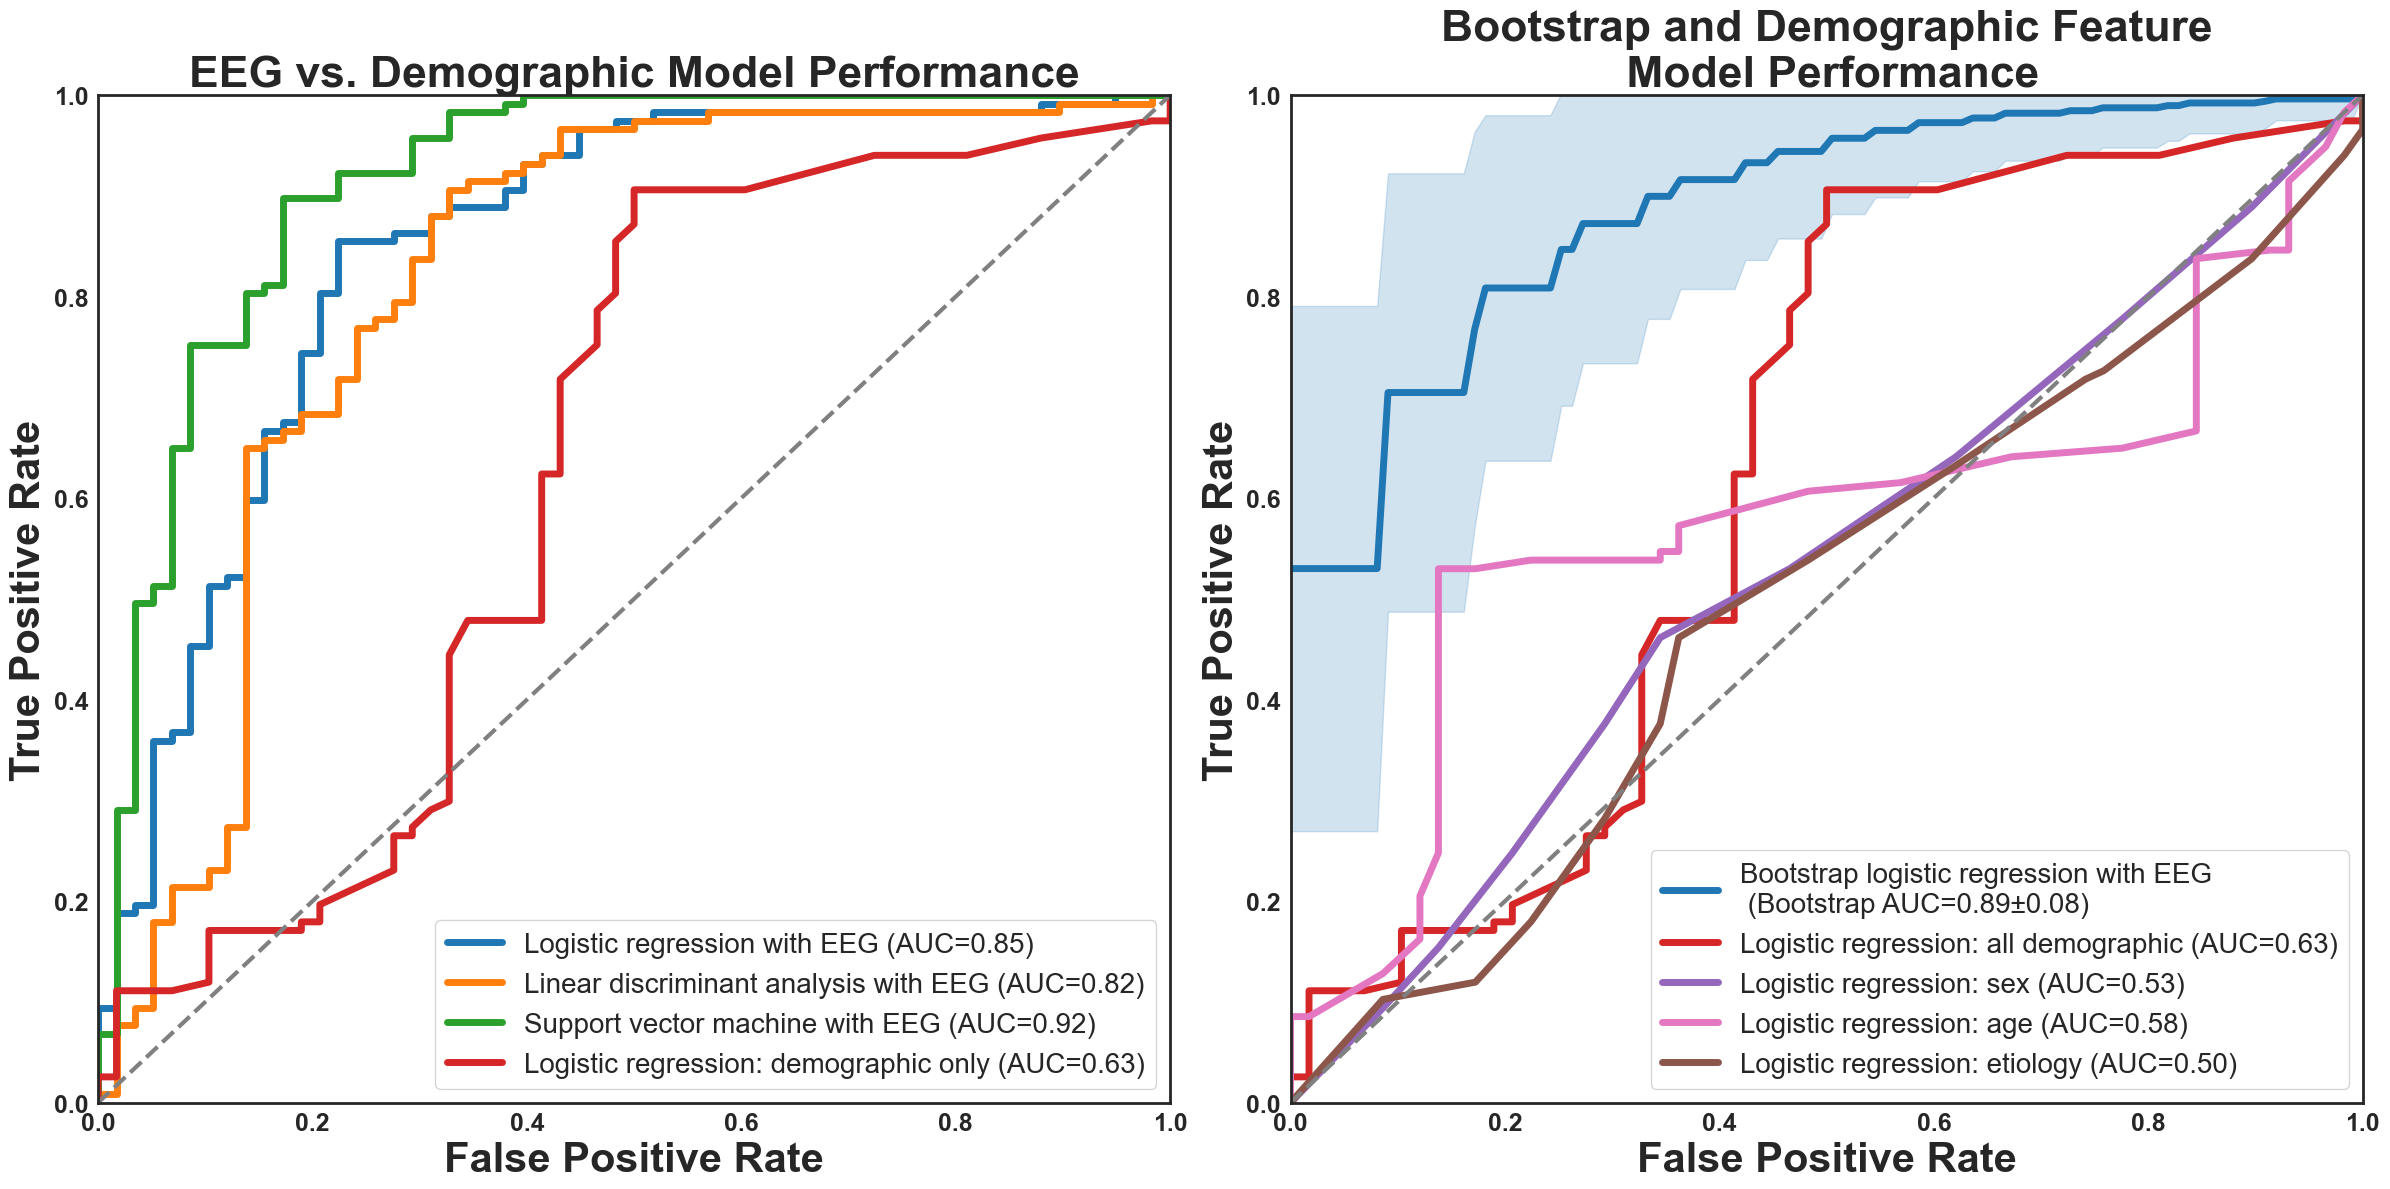

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc, classification_report
from sklearn.utils import resample
from tqdm import tqdm

# Initialize variables for ROC curves and bootstrap results
combined_fpr_tpr = {}
bootstrap_results = []
n_bootstraps = 1000
target_size = len(y[y==0]) # Desired size for balanced classes which is 58
all_fprs = np.linspace(0, 1, 100)

# Colors for consistency
color_map = {
    'Logistic regression with EEG': 'C0',
    'Linear discriminant analysis with EEG': 'C1',
    'Support vector machine with EEG': 'C2',
    'Logistic regression: all demographic': 'C3',
    'Logistic regression: sex': 'C4',
    'Logistic regression: age': 'C6',
    'Logistic regression: etiology': 'C5'
}

# Subplot setup
fig, axes = plt.subplots(1, 2, figsize=(24, 12))

# Adjust spines for both subplots
for ax in axes:
    ax.spines['top'].set_linewidth(2)
    ax.spines['right'].set_linewidth(2)
    ax.spines['left'].set_linewidth(2)
    ax.spines['bottom'].set_linewidth(2)

# ---- Left plot: Full model + Etiology+Sex+Age ---- #
# Logistic Regression, LDA, and SVM for Features+Etiology+Sex+Age
for model_name, model_data in {'with EEG': X_scaled}.items():
    combined_fpr_tpr[model_name] = {}
    
    # Logistic Regression
    lr_conf_matrix, lr_true_labels, lr_predictions, lr_predict_probs, _ = evaluate_model(
        LogisticRegression(random_state=42), model_data, y, skf)
    fpr_lr, tpr_lr, _ = roc_curve(lr_true_labels, lr_predict_probs)
    roc_auc_lr = auc(fpr_lr, tpr_lr)
    axes[0].plot(fpr_lr, tpr_lr, label=f'Logistic regression {model_name} (AUC={roc_auc_lr:.2f})', lw=5, color=color_map['Logistic regression with EEG'])
    
    # LDA
    lda_conf_matrix, lda_true_labels, lda_predictions, lda_predict_probs, _ = evaluate_model(
        LDA(), model_data, y, skf)
    fpr_lda, tpr_lda, _ = roc_curve(lda_true_labels, lda_predict_probs)
    roc_auc_lda = auc(fpr_lda, tpr_lda)
    axes[0].plot(fpr_lda, tpr_lda, label=f'Linear discriminant analysis {model_name} (AUC={roc_auc_lda:.2f})', lw=5, color=color_map['Linear discriminant analysis with EEG'])
    
    # SVM
    svm_conf_matrix, svm_true_labels, svm_predictions, svm_predict_probs, _ = evaluate_model(
        SVC(probability=True, random_state=42), model_data, y, skf)
    fpr_svm, tpr_svm, _ = roc_curve(svm_true_labels, svm_predict_probs)
    roc_auc_svm = auc(fpr_svm, tpr_svm)
    axes[0].plot(fpr_svm, tpr_svm, label=f'Support vector machine {model_name} (AUC={roc_auc_svm:.2f})', lw=5, color=color_map['Support vector machine with EEG'])

# Logistic Regression for Etiology+Sex+Age
for model_name, model_data in {'demographic only': X_control_scaled}.items():
    lr_conf_matrix, lr_true_labels, lr_predictions, lr_predict_probs, _ = evaluate_model(
        LogisticRegression(random_state=42), model_data, y, skf)
    fpr, tpr, _ = roc_curve(lr_true_labels, lr_predict_probs)
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, label=f'Logistic regression: {model_name} (AUC={roc_auc:.2f})', lw=5, color=color_map['Logistic regression: all demographic'])

axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--', lw=3)
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.0])
axes[0].set_xlabel('False Positive Rate', fontsize=30, fontweight='bold')
axes[0].set_ylabel('True Positive Rate', fontsize=30, fontweight='bold')
axes[0].set_title('EEG vs. Demographic Model Performance', fontsize=32, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=20)

# ---- Right plot: Bootstrap + Combined controls ---- #
# Bootstrap for Features+Etiology+Sex+Age with Logistic Regression
tprs, aucs = [], []
for _ in range(n_bootstraps):
    # Bootstrap and balance dataset
    X_recovered, y_recovered = X_scaled[y == 1], y[y == 1]
    X_nonrecovered, y_nonrecovered = X_scaled[y == 0], y[y == 0]

    X_resampled_rec, y_resampled_rec = resample(
        X_recovered, y_recovered, replace=True, n_samples=target_size, random_state=None
    )
    X_resampled_nonrec, y_resampled_nonrec = resample(
        X_nonrecovered, y_nonrecovered, replace=True, n_samples=target_size, random_state=None
    )

    X_resampled = np.vstack((X_resampled_rec, X_resampled_nonrec))
    y_resampled = np.hstack((y_resampled_rec, y_resampled_nonrec))
    
    # Perform StratifiedKFold cross-validation
    #skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    for train_index, test_index in skf.split(X_resampled, y_resampled):
        X_train, X_test = X_resampled[train_index], X_resampled[test_index]
        y_train, y_test = y_resampled[train_index], y_resampled[test_index]
        
        # Logistic Regression
        model = LogisticRegression(random_state=42)
        model.fit(X_train, y_train)
        y_prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)
        tprs.append(np.interp(all_fprs, fpr, tpr))
        aucs.append(roc_auc)


mean_tpr = np.mean(tprs, axis=0)
std_tpr = np.std(tprs, axis=0)
mean_auc = np.mean(aucs)
std_auc = np.std(aucs)
axes[1].plot(all_fprs, mean_tpr, label=f'Bootstrap logistic regression with EEG\n (Bootstrap AUC={mean_auc:.2f}±{std_auc:.2f})', color=color_map['Logistic regression with EEG'], lw=5)
axes[1].fill_between(all_fprs, mean_tpr - std_tpr, mean_tpr + std_tpr, alpha=0.2, color=color_map['Logistic regression with EEG'])

# Combined controls
for model_name, model_data in {
    'all demographic': X_control_scaled,
    'sex': X_control_sex,
    'age': X_control_age,
    'etiology': X_control_etiology
}.items():
    lr_conf_matrix, lr_true_labels, lr_predictions, lr_predict_probs, _ = evaluate_model(
        LogisticRegression(random_state=42), model_data, y, skf)
    fpr, tpr, _ = roc_curve(lr_true_labels, lr_predict_probs)
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, lw=5, color=color_map[f'Logistic regression: {model_name}'], label=f'Logistic regression: {model_name} (AUC={roc_auc:.2f})')

axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', lw=3)
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.0])
axes[1].set_xlabel('False Positive Rate', fontsize=30, fontweight='bold')
axes[1].set_ylabel('True Positive Rate', fontsize=30, fontweight='bold')
axes[1].set_title('Bootstrap and Demographic Feature\n Model Performance', fontsize=32, fontweight='bold')
axes[1].legend(loc='lower right', fontsize=20)

for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=18)  # Set label size
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('bold')  # Set font weight to bold
     
# Finalize and save plots
plt.tight_layout()
#plt.suptitle('Receiver Operating Characteristic (ROC) Curves', fontsize=36, fontweight='bold')
plt.savefig(f'/Users/derek/Documents/PICU/Manuscript_analysis/Manuscript Redo/Figures/tif_figures/roc_curve_combined_subplot.tif', dpi=600, format='tif', bbox_inches='tight')
plt.show()

In [108]:
import numpy as np
import pandas as pd
from pathlib import Path

# --- config (reuse from your earlier code) ---
ETIOLOGY_COL = 'injury_etiology_cleaned'
SEX_COL      = 'Sex'
AGE_COL      = 'age_years'
LABEL_COL    = 'recovery'              # optional in df_test
METRIC_COLS  = metric_interested       # your metrics list
SAVE_DIR = Path(png_save_folder) if 'png_save_folder' in globals() else Path('.')

# Patient ID candidates (edit/extend if needed)
ID_CANDIDATES = ['Participant ID', 'Participant', 'patient_id', 'subject', 'ID', 'sub']

# --- find ID column ---
id_col = next((c for c in ID_CANDIDATES if c in df_test.columns), None)
if id_col is None:
    raise ValueError(f"Could not find a patient id column in df_test. Looked for: {ID_CANDIDATES}")

# --- helpers ---
def mode_or_nan(s: pd.Series):
    m = s.mode(dropna=True)
    return m.iloc[0] if not m.empty else np.nan

# --- aggregate per-patient ---
agg_specs = {m: 'mean' for m in METRIC_COLS}
agg_specs[AGE_COL] = 'mean'
agg_specs[SEX_COL] = mode_or_nan
agg_specs[ETIOLOGY_COL] = mode_or_nan
if LABEL_COL in df_test.columns:
    agg_specs[LABEL_COL] = mode_or_nan

df_pat = df_test.groupby(id_col, dropna=False).agg(agg_specs).reset_index()

print("Per-patient aggregated table (head):")
print(df_pat.head().to_string(index=False))

Per-patient aggregated table (head):
Participant ID   SampEn      PEn    CWPEn      LZC       LE  HiguchiFD  dfaAlpha  FOOOF_Offset  FOOOF_Slope  |delta|Power  |theta|Power  |alpha|Power  |beta|Power  |low-gamma|Power  age_years    Sex injury_etiology_cleaned  recovery
     sub-026MC 0.397366 0.906607 0.092735 0.270794 0.002000   1.921038  0.518669     -0.698318     1.739149      0.255691      0.194774      0.043215     0.030934          0.011848       16.0   Male         Systemic Injury         0
     sub-032MC 0.109953 0.869793 0.084224 0.244930 0.001540   1.911526  0.663895     -0.452321     2.284171      0.303922      0.048755      0.045425     0.024264          0.002212       14.0 Female         Systemic Injury         1
     sub-040MC 0.250516 0.843375 0.116926 0.313900 0.004214   1.906894  0.651463     -0.860945     1.780228      0.270028      0.018881      0.010418     0.064259          0.004867       10.0 Female         Systemic Injury         1


In [109]:
# --- transform to model features with your *fitted* encoders/scaler ---
def make_X_from_df(df):
    # use the previously-fitted onehot_etiology, onehot_sex, and scaler_full
    eti = onehot_etiology.transform(df[[ETIOLOGY_COL]])
    sex = onehot_sex.transform(df[[SEX_COL]])
    age = df[[AGE_COL]].to_numpy()
    met = df[METRIC_COLS].to_numpy()
    X_full = np.hstack([eti, sex, age, met])
    X_scaled = scaler_full.transform(X_full)
    return X_scaled

X_pat = make_X_from_df(df_pat)
y_pat = df_pat[LABEL_COL].astype(int).values if LABEL_COL in df_pat.columns else None
has_labels = y_pat is not None

# --- predict with all trained models ---
def predict_all(models_dict, X, ids, y_true=None):
    rows = []
    for name, clf in models_dict.items():
        proba = clf.predict_proba(X)[:, 1]
        pred  = (proba >= 0.5).astype(int)
        for i, pid in enumerate(ids):
            row = {
                id_col: pid,
                'model': name,
                'prob_recovered': float(proba[i]),
                'prob_not_recovered': float(1.0 - proba[i]),
                'pred_label': int(pred[i]),
            }
            if y_true is not None:
                row['true_label'] = int(y_true[i])
                row['correct'] = int(row['pred_label'] == row['true_label'])
            rows.append(row)
    return pd.DataFrame(rows)

pred_pat = predict_all(models, X_pat, df_pat[id_col].astype(str).values, y_pat)

# pretty print per model
for name in pred_pat['model'].unique():
    print(f"\n===== {name} (per-patient) =====")
    print(pred_pat[pred_pat['model'] == name]
          [[id_col, 'prob_recovered', 'prob_not_recovered', 'pred_label'] + (['true_label','correct'] if has_labels else [])]
          .to_string(index=False))


===== LR_with_EEG (per-patient) =====
Participant ID  prob_recovered  prob_not_recovered  pred_label  true_label  correct
     sub-026MC        0.680236            0.319764           1           0        0
     sub-032MC        0.968637            0.031363           1           1        1
     sub-040MC        0.797864            0.202136           1           1        1

===== LDA_with_EEG (per-patient) =====
Participant ID  prob_recovered  prob_not_recovered  pred_label  true_label  correct
     sub-026MC        0.853429            0.146571           1           0        0
     sub-032MC        0.984780            0.015220           1           1        1
     sub-040MC        0.939625            0.060375           1           1        1

===== SVM_with_EEG (per-patient) =====
Participant ID  prob_recovered  prob_not_recovered  pred_label  true_label  correct
     sub-026MC        0.704723            0.295277           1           0        0
     sub-032MC        0.957182           

In [ ]:
#---- Print Classification Reports ---- #
print("\nClassification Reports for Logistic Regression, LDA, and SVM Models:\n")

# Classification Report for Features+Etiology+Sex+Age
for model_name, model_data in {'Features+Etiology+Sex+Age': X_scaled}.items():
    # Logistic Regression
    _, lr_true_labels, lr_predictions, _, _ = evaluate_model(
        LogisticRegression(random_state=42), model_data, y, skf)
    print(f"Classification Report for {model_name} - Logistic Regression:")
    print(classification_report(lr_true_labels, lr_predictions, target_names=['Non-Recovered', 'Recovered']))
    
    # LDA
    _, lda_true_labels, lda_predictions, _, _ = evaluate_model(
        LDA(), model_data, y, skf)
    print(f"\nClassification Report for {model_name} - LDA:")
    print(classification_report(lda_true_labels, lda_predictions, target_names=['Non-Recovered', 'Recovered']))
    
    # SVM
    _, svm_true_labels, svm_predictions, _, _ = evaluate_model(
        SVC(probability=True, random_state=42), model_data, y, skf)
    print(f"\nClassification Report for {model_name} - SVM:")
    print(classification_report(svm_true_labels, svm_predictions, target_names=['Non-Recovered', 'Recovered']))

# Classification Report for Controls
for model_name, model_data in {
    'Etiology+Sex+Age': X_control_scaled,
    'Sex': X_control_sex,
    'Age': X_control_age,
    'Etiology': X_control_etiology
}.items():
    _, control_true_labels, control_predictions, _, _ = evaluate_model(
        LogisticRegression(random_state=42), model_data, y, skf)
    print(f"\nClassification Report for {model_name} - Logistic Regression:")
    print(classification_report(control_true_labels, control_predictions, target_names=['Non-Recovered', 'Recovered']))


Classification Reports for Logistic Regression, LDA, and SVM Models:

Classification Report for Features+Etiology+Sex+Age - Logistic Regression:
               precision    recall  f1-score   support

Non-Recovered       0.75      0.66      0.70        58
    Recovered       0.84      0.89      0.86       117

     accuracy                           0.81       175
    macro avg       0.79      0.77      0.78       175
 weighted avg       0.81      0.81      0.81       175


Classification Report for Features+Etiology+Sex+Age - LDA:
               precision    recall  f1-score   support

Non-Recovered       0.72      0.67      0.70        58
    Recovered       0.84      0.87      0.86       117

     accuracy                           0.81       175
    macro avg       0.78      0.77      0.78       175
 weighted avg       0.80      0.81      0.80       175


Classification Report for Features+Etiology+Sex+Age - SVM:
               precision    recall  f1-score   support

Non-Recovere

# More Control Models 

In [ ]:
CRIT_ONLY = metric_interested[:9]
PSD_ONLY = metric_interested[9:]
CRIT_ONLY_DATA = df_filtered[CRIT_ONLY].values
PSD_ONLY_DATA = df_filtered[PSD_ONLY].values

NEW_x_Spectral_D = np.hstack((etiology_encoded, sex_encoded, age, PSD_ONLY_DATA)) 
NEW_x_CRIT_D = np.hstack((etiology_encoded, sex_encoded, age, CRIT_ONLY_DATA))

NEW_SD = scaler.fit_transform(NEW_x_Spectral_D)
NEW_CD = scaler.fit_transform(NEW_x_CRIT_D)

# X_scaled = FULL

In [ ]:
print(X_metrics_pca.shape)
print(NEW_CD.shape)
print(NEW_SD.shape)

(175, 4)
(175, 15)
(175, 11)


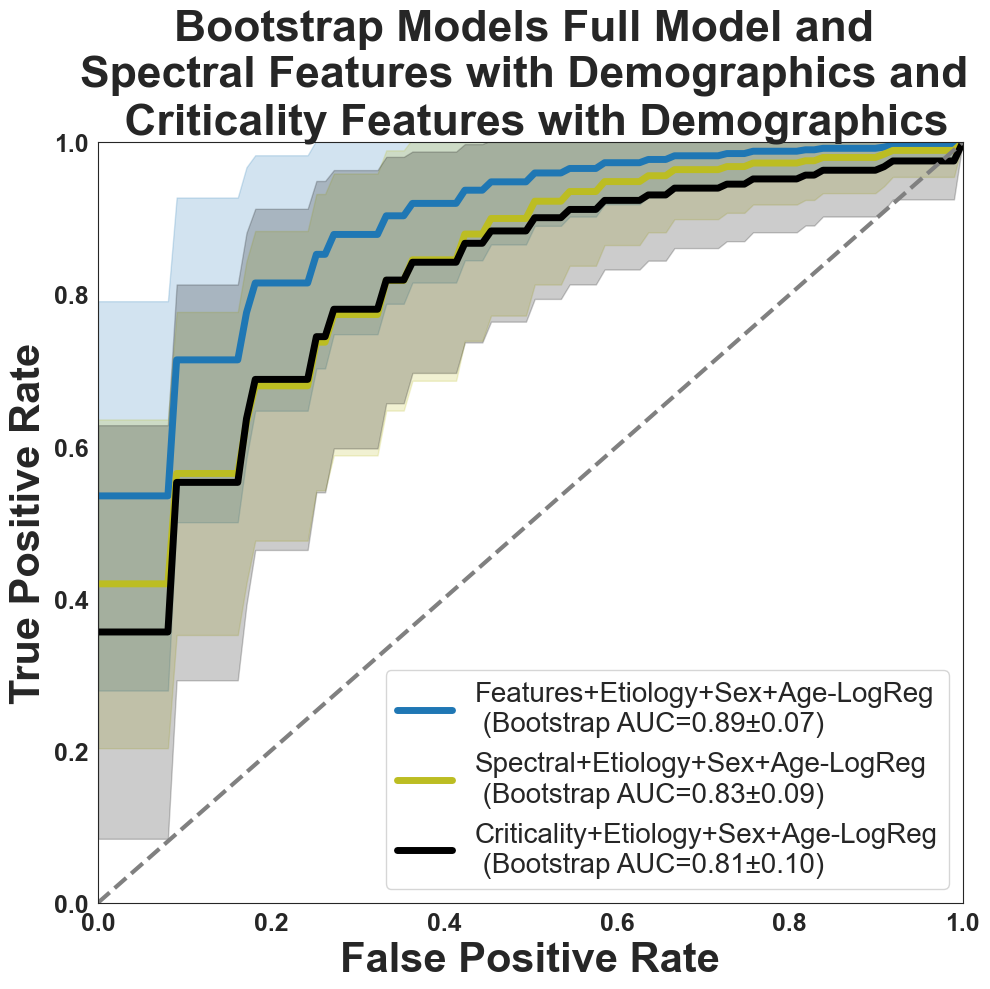

In [ ]:
# Test

# Initialize variables for ROC curves and bootstrap results
combined_fpr_tpr = {}
bootstrap_results = []
n_bootstraps = 1000
target_size = 58  # Desired size for balanced classes
all_fprs = np.linspace(0, 1, 100)

# Colors for consistency
color_map = {
    'Features+Etiology+Sex+Age-LogReg': 'C0',
    'Features+Etiology+Sex+Age-LDA': 'C1',
    'Features+Etiology+Sex+Age-SVM': 'C2',
    'Etiology+Sex+Age-LogReg': 'C3',
    'Sex-LogReg': 'C4',
    'Age-LogReg': 'C6',
    'Etiology-LogReg': 'C5',
    'Spectral+Etiology+Sex+Age-LogReg':'C8',
    'Criticality+Etiology+Sex+Age-LogReg':'k'
}

# Subplot setup
fig, axes = plt.subplots(1, 1, figsize=(10, 10))

# ---- Right plot: Bootstrap + Combined controls ---- #
tprs, aucs = [], []
for _ in range(n_bootstraps):
    # Bootstrap and balance dataset
    X_recovered, y_recovered = X_scaled[y == 1], y[y == 1]
    X_nonrecovered, y_nonrecovered = X_scaled[y == 0], y[y == 0]

    X_resampled_rec, y_resampled_rec = resample(
        X_recovered, y_recovered, replace=True, n_samples=target_size, random_state=None
    )
    X_resampled_nonrec, y_resampled_nonrec = resample(
        X_nonrecovered, y_nonrecovered, replace=True, n_samples=target_size, random_state=None
    )

    X_resampled = np.vstack((X_resampled_rec, X_resampled_nonrec))
    y_resampled = np.hstack((y_resampled_rec, y_resampled_nonrec))
    
    # Perform StratifiedKFold cross-validation
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    for train_index, test_index in skf.split(X_resampled, y_resampled):
        X_train, X_test = X_resampled[train_index], X_resampled[test_index]
        y_train, y_test = y_resampled[train_index], y_resampled[test_index]
        
        # Logistic Regression
        model = LogisticRegression(random_state=42)
        model.fit(X_train, y_train)
        y_prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)
        tprs.append(np.interp(all_fprs, fpr, tpr))
        aucs.append(roc_auc)

mean_tpr = np.mean(tprs, axis=0)
std_tpr = np.std(tprs, axis=0)
mean_auc = np.mean(aucs)
std_auc = np.std(aucs)
axes.plot(all_fprs, mean_tpr, label=f'Features+Etiology+Sex+Age-LogReg\n (Bootstrap AUC={mean_auc:.2f}±{std_auc:.2f})', color=color_map['Features+Etiology+Sex+Age-LogReg'], lw=5)
axes.fill_between(all_fprs, mean_tpr - std_tpr, mean_tpr + std_tpr, alpha=0.2, color=color_map['Features+Etiology+Sex+Age-LogReg'])

tprs_SD, aucs_SD = [], []
for _ in range(n_bootstraps):
    # Bootstrap and balance dataset
    X_recovered, y_recovered = NEW_SD[y == 1], y[y == 1]
    X_nonrecovered, y_nonrecovered = NEW_SD[y == 0], y[y == 0]

    X_resampled_rec, y_resampled_rec = resample(
        X_recovered, y_recovered, replace=True, n_samples=target_size, random_state=None
    )
    X_resampled_nonrec, y_resampled_nonrec = resample(
        X_nonrecovered, y_nonrecovered, replace=True, n_samples=target_size, random_state=None
    )

    X_resampled = np.vstack((X_resampled_rec, X_resampled_nonrec))
    y_resampled = np.hstack((y_resampled_rec, y_resampled_nonrec))
    
    # Perform StratifiedKFold cross-validation
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    for train_index, test_index in skf.split(X_resampled, y_resampled):
        X_train, X_test = X_resampled[train_index], X_resampled[test_index]
        y_train, y_test = y_resampled[train_index], y_resampled[test_index]
        
        # Logistic Regression
        model = LogisticRegression(random_state=42)
        model.fit(X_train, y_train)
        y_prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)
        tprs_SD.append(np.interp(all_fprs, fpr, tpr))
        aucs_SD.append(roc_auc)

mean_tpr_SD = np.mean(tprs_SD, axis=0)
std_tpr_SD = np.std(tprs_SD, axis=0)
mean_auc_SD = np.mean(aucs_SD)
std_auc_SD = np.std(aucs_SD)
axes.plot(all_fprs, mean_tpr_SD, label=f'Spectral+Etiology+Sex+Age-LogReg\n (Bootstrap AUC={mean_auc_SD:.2f}±{std_auc_SD:.2f})', color=color_map['Spectral+Etiology+Sex+Age-LogReg'], lw=5)
axes.fill_between(all_fprs, mean_tpr_SD - std_tpr_SD, mean_tpr_SD + std_tpr_SD, alpha=0.2, color=color_map['Spectral+Etiology+Sex+Age-LogReg'])

tprs_CD, aucs_CD = [], []
for _ in range(n_bootstraps):
    # Bootstrap and balance dataset
    X_recovered, y_recovered = NEW_CD[y == 1], y[y == 1]
    X_nonrecovered, y_nonrecovered = NEW_CD[y == 0], y[y == 0]

    X_resampled_rec, y_resampled_rec = resample(
        X_recovered, y_recovered, replace=True, n_samples=target_size, random_state=None
    )
    X_resampled_nonrec, y_resampled_nonrec = resample(
        X_nonrecovered, y_nonrecovered, replace=True, n_samples=target_size, random_state=None
    )

    X_resampled = np.vstack((X_resampled_rec, X_resampled_nonrec))
    y_resampled = np.hstack((y_resampled_rec, y_resampled_nonrec))
    
    # Perform StratifiedKFold cross-validation
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    for train_index, test_index in skf.split(X_resampled, y_resampled):
        X_train, X_test = X_resampled[train_index], X_resampled[test_index]
        y_train, y_test = y_resampled[train_index], y_resampled[test_index]
        
        # Logistic Regression
        model = LogisticRegression(random_state=42)
        model.fit(X_train, y_train)
        y_prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)
        tprs_CD.append(np.interp(all_fprs, fpr, tpr))
        aucs_CD.append(roc_auc)

mean_tpr_CD = np.mean(tprs_CD, axis=0)
std_tpr_CD = np.std(tprs_CD, axis=0)
mean_auc_CD = np.mean(aucs_CD)
std_auc_CD = np.std(aucs_CD)
axes.plot(all_fprs, mean_tpr_CD, label=f'Criticality+Etiology+Sex+Age-LogReg\n (Bootstrap AUC={mean_auc_CD:.2f}±{std_auc_CD:.2f})', color=color_map['Criticality+Etiology+Sex+Age-LogReg'], lw=5)
axes.fill_between(all_fprs, mean_tpr_CD - std_tpr_CD, mean_tpr_CD + std_tpr_CD, alpha=0.2, color=color_map['Criticality+Etiology+Sex+Age-LogReg'])

# Adjust ticks
axes.tick_params(axis='both', which='major', labelsize=18)  # Set label size
for label in axes.get_xticklabels() + axes.get_yticklabels():
    label.set_fontweight('bold')  # Set font weight to bold

axes.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=3)
axes.set_xlim([0.0, 1.0])
axes.set_ylim([0.0, 1.0])
axes.set_xlabel('False Positive Rate', fontsize=30, fontweight='bold')
axes.set_ylabel('True Positive Rate', fontsize=30, fontweight='bold')
axes.set_title('Bootstrap Models Full Model and \nSpectral Features with Demographics and \n Criticality Features with Demographics', fontsize=32, fontweight='bold')
axes.legend(loc='lower right', fontsize=20)

# Finalize and save plots
plt.tight_layout()
#plt.savefig(f'{png_save_folder}/TEST_SDvsCDvsFull.png', dpi=300)
plt.show()

# BOOTSTRAP 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc, classification_report
from sklearn.utils import resample
from tqdm import tqdm

n_bootstraps = 1000
target_size = len(y[y==0]) # Desired size for balanced classes which is 58
all_fprs = np.linspace(0, 1, 100)

def evaluate_model_bs(model, X, y, skf):
    conf_matrices = []
    true_labels, predictions = [], []
    predict_probs = []
    coefficients = []

    for train_index, test_index in skf.split(X, y):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]
        
        predict_probs.extend(y_prob)
        conf_matrices.append(confusion_matrix(y_test, y_pred, labels=[0, 1]))
        true_labels.extend(y_test)
        predictions.extend(y_pred)
        if hasattr(model, 'coef_'):
            coefficients.append(model.coef_[0])
    
    report = classification_report(true_labels, predictions, output_dict=True)

    final_conf_matrix = np.sum(conf_matrices, axis=0)
    if coefficients:
        mean_coefficients = np.array(coefficients).mean(axis=0)
    else:
        mean_coefficients = None

    return final_conf_matrix, np.array(true_labels), np.array(predictions), np.array(predict_probs), mean_coefficients, report

# Initialize storage for classification reports
bootstrap_results = {
    'confusions': [],
    'true_labels': [],
    'predictions': [],
    'predict_probs': [],
    'mean_coefficients': [],
    'classification_reports': []
}

# Perform bootstrapping (right plot logic)
for _ in range(n_bootstraps):
    # Bootstrap and balance dataset
    X_recovered, y_recovered = X_scaled[y == 1], y[y == 1]
    X_nonrecovered, y_nonrecovered = X_scaled[y == 0], y[y == 0]

    X_resampled_rec, y_resampled_rec = resample(
        X_recovered, y_recovered, replace=True, n_samples=target_size, random_state=None
    )
    X_resampled_nonrec, y_resampled_nonrec = resample(
        X_nonrecovered, y_nonrecovered, replace=True, n_samples=target_size, random_state=None
    )

    X_resampled = np.vstack((X_resampled_rec, X_resampled_nonrec))
    y_resampled = np.hstack((y_resampled_rec, y_resampled_nonrec))

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    results = evaluate_model_bs(LogisticRegression(random_state=42), X_resampled, y_resampled, skf)
    bootstrap_results['confusions'].append(results[0])
    bootstrap_results['true_labels'].append(results[1])
    bootstrap_results['predictions'].append(results[2])
    bootstrap_results['predict_probs'].append(results[3])
    bootstrap_results['mean_coefficients'].append(results[4])
    bootstrap_results['classification_reports'].append(results[5])

In [ ]:
from collections import defaultdict

# Initialize storage for aggregated metrics
aggregated_metrics = defaultdict(lambda: defaultdict(list))
macro_avg_metrics = defaultdict(list)
weighted_avg_metrics = defaultdict(list)
accuracy_values = []


# Collect metrics from all bootstrap classification reports
for report in bootstrap_results['classification_reports']:
    for key, metrics in report.items():
        if key == 'accuracy':
            # Collect accuracy separately
            accuracy_values.append(metrics)
        elif key not in ['macro avg', 'weighted avg']:
            # Aggregate metrics for individual classes (e.g., '0' and '1')
            for metric, value in metrics.items():
                aggregated_metrics[key][metric].append(value)
        elif key == 'macro avg':
            # Aggregate macro avg metrics separately
            for metric, value in metrics.items():
                macro_avg_metrics[metric].append(value)
        elif key == 'weighted avg':
            # Aggregate weighted avg metrics separately
            for metric, value in metrics.items():
                weighted_avg_metrics[metric].append(value)
                
# Compute mean and standard deviation for each metric
average_report = {}

# For individual class metrics
for key, metrics in aggregated_metrics.items():
    average_report[key] = {}
    for metric, values in metrics.items():
        average_report[key][metric] = {
            'mean': np.mean(values),
            'std': np.std(values)
        }

# For macro avg metrics
average_report['macro avg'] = {
    metric: {'mean': np.mean(values), 'std': np.std(values)}
    for metric, values in macro_avg_metrics.items()
}

# For weighted avg metrics
average_report['weighted avg'] = {
    metric: {'mean': np.mean(values), 'std': np.std(values)}
    for metric, values in weighted_avg_metrics.items()
}
# For accuracy
average_report['accuracy'] = {
    'mean': np.mean(accuracy_values),
    'std': np.std(accuracy_values)
}

In [ ]:
print(np.mean(bootstrap_results['confusions'],axis=0))
print(np.std(bootstrap_results['confusions'],axis=0))

[[46.86  11.14 ]
 [10.833 47.167]]
[[3.0120425  3.0120425 ]
 [3.05599591 3.05599591]]


In [ ]:
print(np.mean(bootstrap_results['confusions'],axis=0))
print(np.std(bootstrap_results['confusions'],axis=0))

[[46.808 11.192]
 [10.836 47.164]]
[[2.81587216 2.81587216]
 [3.03991842 3.03991842]]


In [ ]:
print(np.mean(bootstrap_results['mean_coefficients'],axis=0))
print(np.std(bootstrap_results['mean_coefficients'],axis=0))

[-0.11202423 -0.03143822  0.10030027  0.06881622 -0.06881622 -0.16579349
 -1.19549927  0.12171713 -0.12156269  0.51329304 -0.59241107  0.41011938
  0.07322869 -0.22684162 -0.70367522 -0.14148568 -0.0941568   0.91016767
  1.50073404 -1.49332386]
[0.28014626 0.16356716 0.17313009 0.13583983 0.13583983 0.26070438
 0.30650861 0.32721143 0.24555823 0.35399161 0.31128375 0.26210332
 0.31542335 0.3167418  0.28565059 0.27730764 0.30671206 0.30146926
 0.23989012 0.29899158]


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import itertools
import seaborn as sns

sns.set_style('white')

def plot_confusion_matrix(mean_cm, std_cm, classes, normalize=False, title='Confusion matrix', cmap=plt.cm.Blues):

    if normalize:
        mean_cm = mean_cm.astype('float') / mean_cm.sum(axis=1)[:, np.newaxis]
        std_cm = std_cm.astype('float') / mean_cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print("Mean CM:\n", mean_cm)
    print("STD CM:\n", std_cm)

    plt.figure(figsize=(6, 6))
    plt.imshow(mean_cm, interpolation='nearest', cmap=cmap)
    plt.title(title, fontsize=22, fontweight='bold')
    plt.colorbar(shrink=0.55)
    
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=0, fontsize=14, fontweight='bold')
    plt.yticks(tick_marks, classes, fontsize=14, fontweight='bold')
    
    fmt = '.2f'
    thresh = mean_cm.max() / 2.0
    for i, j in itertools.product(range(mean_cm.shape[0]), range(mean_cm.shape[1])):
        mean_value = format(mean_cm[i, j], fmt)
        std_value = format(std_cm[i, j], fmt)
        value_text = f"{mean_value}\n(±{std_value})"
        
        plt.text(j, i, value_text,
                 horizontalalignment="center",verticalalignment="center",  
                 color="white" if mean_cm[i, j] > thresh else "black",
                 fontsize=18, fontweight='bold')
    
    plt.ylabel('True label', fontsize=24, fontweight='bold')
    plt.xlabel('Predicted label', fontsize=24, fontweight='bold')
    plt.tight_layout()


Confusion matrix, without normalization
Mean CM:
 [[46.86  11.14 ]
 [10.833 47.167]]
STD CM:
 [[3.0120425  3.0120425 ]
 [3.05599591 3.05599591]]


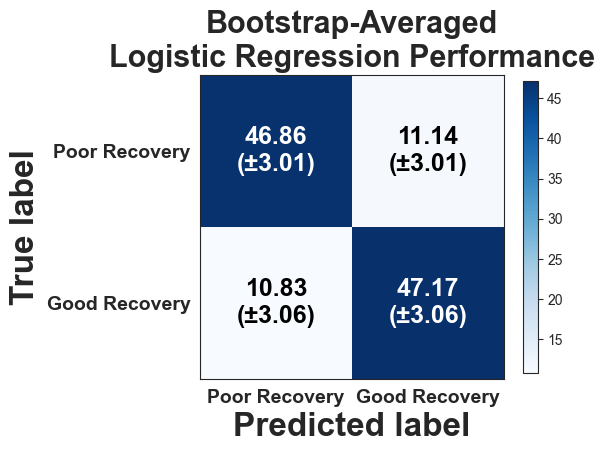

In [ ]:
# Compute mean and standard deviation of confusion matrices
mean_cm = np.mean(bootstrap_results['confusions'], axis=0)
std_cm = np.std(bootstrap_results['confusions'], axis=0)

# Plot the confusion matrix
plot_confusion_matrix(mean_cm, std_cm, classes=['Poor Recovery', 'Good Recovery'], title='Bootstrap-Averaged\nLogistic Regression Performance')

# Save the plot (optional)
#plt.savefig(f'{png_save_folder}/BS_averaged_confusion_matrix_std.png', dpi=300)
plt.show()


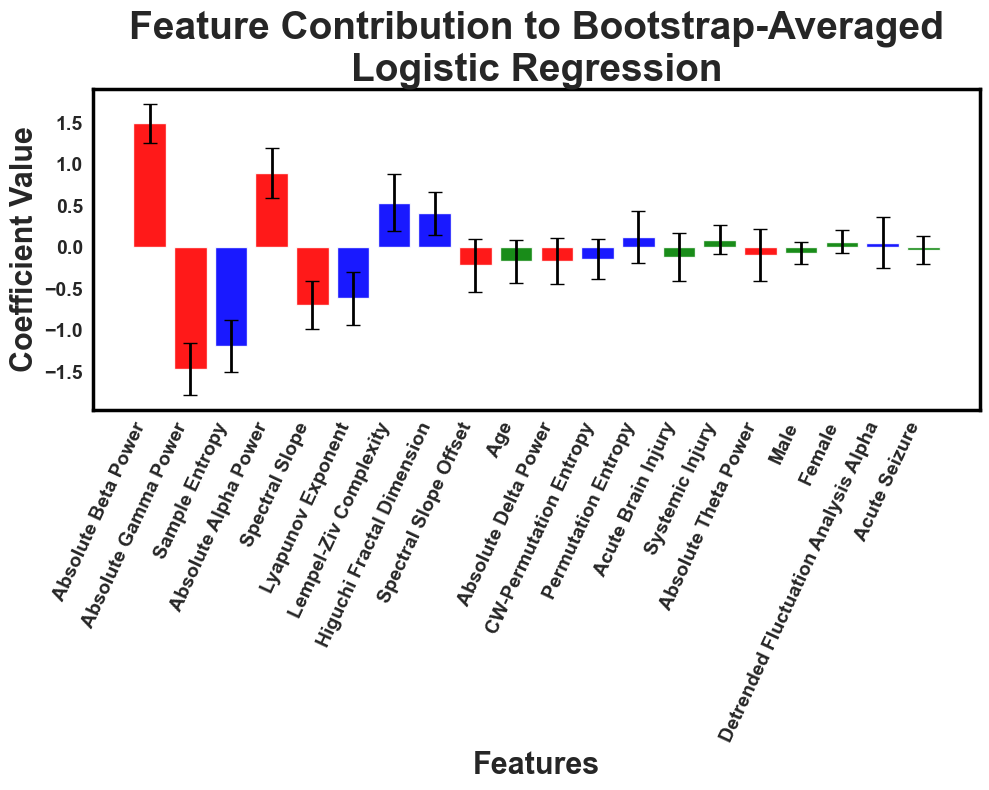

In [ ]:
# Define feature categories and corresponding colors
complexity_metrics = ['Sample Entropy', 'Permutation Entropy', 'CW-Permutation Entropy',
                   'Lempel-Ziv Complexity', 'Lyapunov Exponent', 'Higuchi Fractal Dimension',
                   'Detrended Fluctuation Analysis Alpha']
etiology_sex_age = ['Acute Brain Injury','Acute Seizure','Systemic Injury','Female', 'Male', 'Age']
spectral_metrics = set(all_feature_names) - set(complexity_metrics) - set(etiology_sex_age)  # Remaining features


avg_coeffs = np.mean(bootstrap_results['mean_coefficients'],axis=0)
std_coeffs = np.std(bootstrap_results['mean_coefficients'],axis=0)

category_colors = {
    'Spectral': 'red',
    'Etiology/Sex/Age': 'green',
    'Complexity': 'blue'  # Adjust this color if needed
}


# Assign colors based on feature categories
sorted_indices = np.argsort(np.abs(avg_coeffs))[::-1]
sorted_importance = avg_coeffs[sorted_indices]
sorted_features = [all_feature_names[i] for i in sorted_indices]
sorted_std_coeffs = std_coeffs[sorted_indices]

# Create color list for each feature
bar_colors = []
for feature in sorted_features:
    if feature in complexity_metrics:
        bar_colors.append(category_colors['Complexity'])
    elif feature in etiology_sex_age:
        bar_colors.append(category_colors['Etiology/Sex/Age'])
    elif feature in spectral_metrics:
        bar_colors.append(category_colors['Spectral'])
    else:
        bar_colors.append('gray')  # Use a default color for unexpected features

# Plot sorted features with assigned colors
plt.figure(figsize=(10, 8))

plt.bar(sorted_features, sorted_importance, yerr=sorted_std_coeffs, color=bar_colors, 
        capsize=5, alpha=0.9, error_kw=dict(elinewidth=2, ecolor='black'))
plt.xlabel('Features', fontsize=22, fontweight='bold')
plt.ylabel('Coefficient Value', fontsize=22, fontweight='bold')
plt.title(f'Feature Contribution to Bootstrap-Averaged\nLogistic Regression', fontsize=28, fontweight='bold')
plt.xticks(rotation=65, ha='right', fontsize=14,fontweight='bold')
plt.yticks(fontsize=14,fontweight='bold')

# Customize spines to make them black and bold
ax = plt.gca()  # Get the current axes
for spine in ax.spines.values():
    spine.set_edgecolor('black')  # Set spine color to black
    spine.set_linewidth(2.5)      # Set spine width to make it bold

plt.tight_layout()
#plt.savefig(f'{png_save_folder}/BS_averaged_feature_importance_std.png', dpi=300)
plt.show()

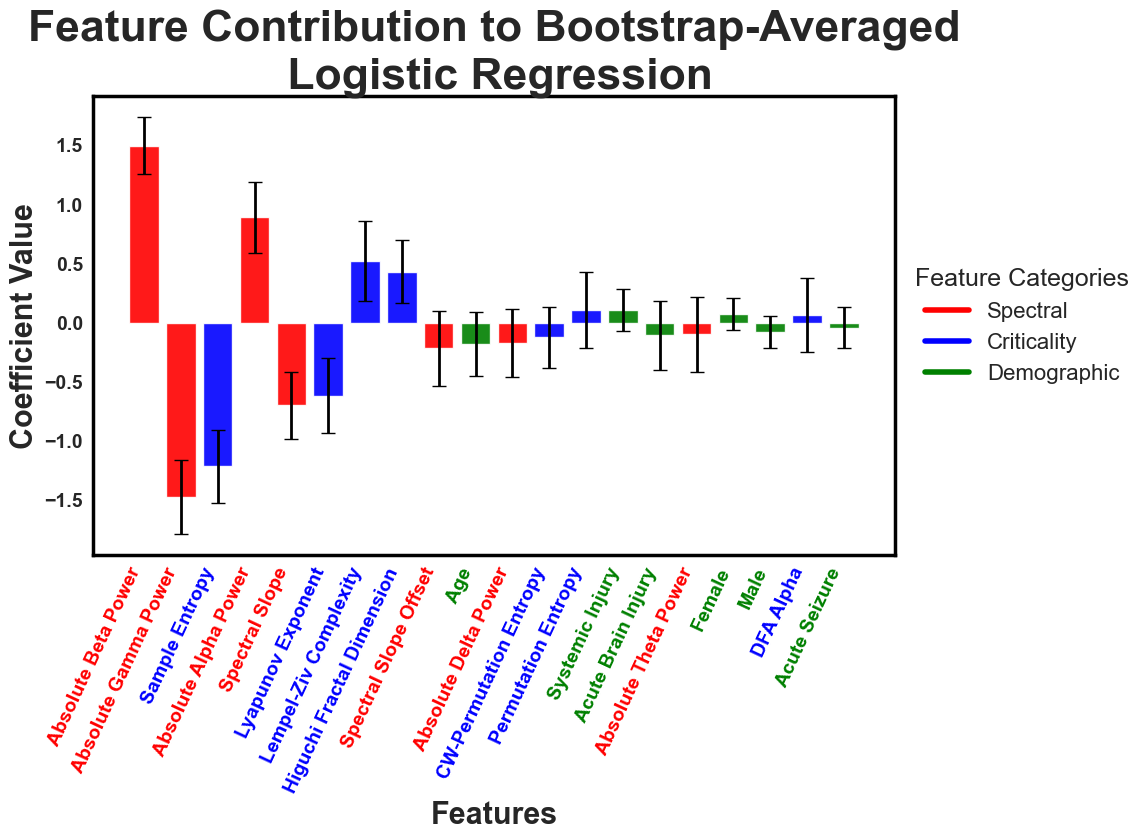

In [ ]:
# Replace long feature names with multi-line versions
formatted_features = [
    feature.replace("Detrended Fluctuation Analysis Alpha", "DFA Alpha")
    for feature in sorted_features
]

# Assign colors based on feature categories (Ensure DFA is blue)
bar_colors = []
for feature in sorted_features:
    feature_name = feature.replace("\n", " ")  # Normalize the name for matching
    if feature_name in complexity_metrics:
        bar_colors.append(category_colors['Complexity'])  # Ensure DFA is blue
    elif feature_name in etiology_sex_age:
        bar_colors.append(category_colors['Etiology/Sex/Age'])
    elif feature_name in spectral_metrics:
        bar_colors.append(category_colors['Spectral'])
    else:
        bar_colors.append('gray')  # Default color for unexpected features

# Plot sorted features with assigned colors
plt.figure(figsize=(12, 8))

bars = plt.bar(formatted_features, sorted_importance, yerr=sorted_std_coeffs, color=bar_colors, 
               capsize=5, alpha=0.9, error_kw=dict(elinewidth=2, ecolor='black'))
plt.xlabel('Features', fontsize=22, fontweight='bold')
plt.ylabel('Coefficient Value', fontsize=22, fontweight='bold')
plt.title(f'Feature Contribution to Bootstrap-Averaged\n Logistic Regression', fontsize=32, fontweight='bold')
plt.xticks(rotation=65, ha='right', fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')

# Get current axis
ax = plt.gca()

# Color x-tick labels based on bar_colors
for xtick, color in zip(ax.get_xticklabels(), bar_colors):
    xtick.set_color(color)  # Set text color for each feature

# Customize spines to make them black and bold
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(2.5)

# Create custom legend (Ensuring DFA shows as blue)
legend_handles = [
    plt.Line2D([0], [0], color=category_colors['Spectral'], lw=4, label='Spectral'),
    plt.Line2D([0], [0], color=category_colors['Complexity'], lw=4, label='Criticality'),
    plt.Line2D([0], [0], color=category_colors['Etiology/Sex/Age'], lw=4, label='Demographic')
]

# Move legend closer to the right side of the figure
plt.legend(handles=legend_handles, title="Feature Categories", fontsize=16, title_fontsize=18, 
           loc="center left", bbox_to_anchor=(1.0, 0.5), frameon=False)  # Moves legend closer

plt.tight_layout()
plt.subplots_adjust(right=0.75, bottom=0.3)  # Adjust margins for spacing

#plt.savefig(f'{png_save_folder}/BS_averaged_feature_importance_std_Coloured.png', dpi=300, bbox_inches='tight')
plt.show()

Confusion matrix, without normalization


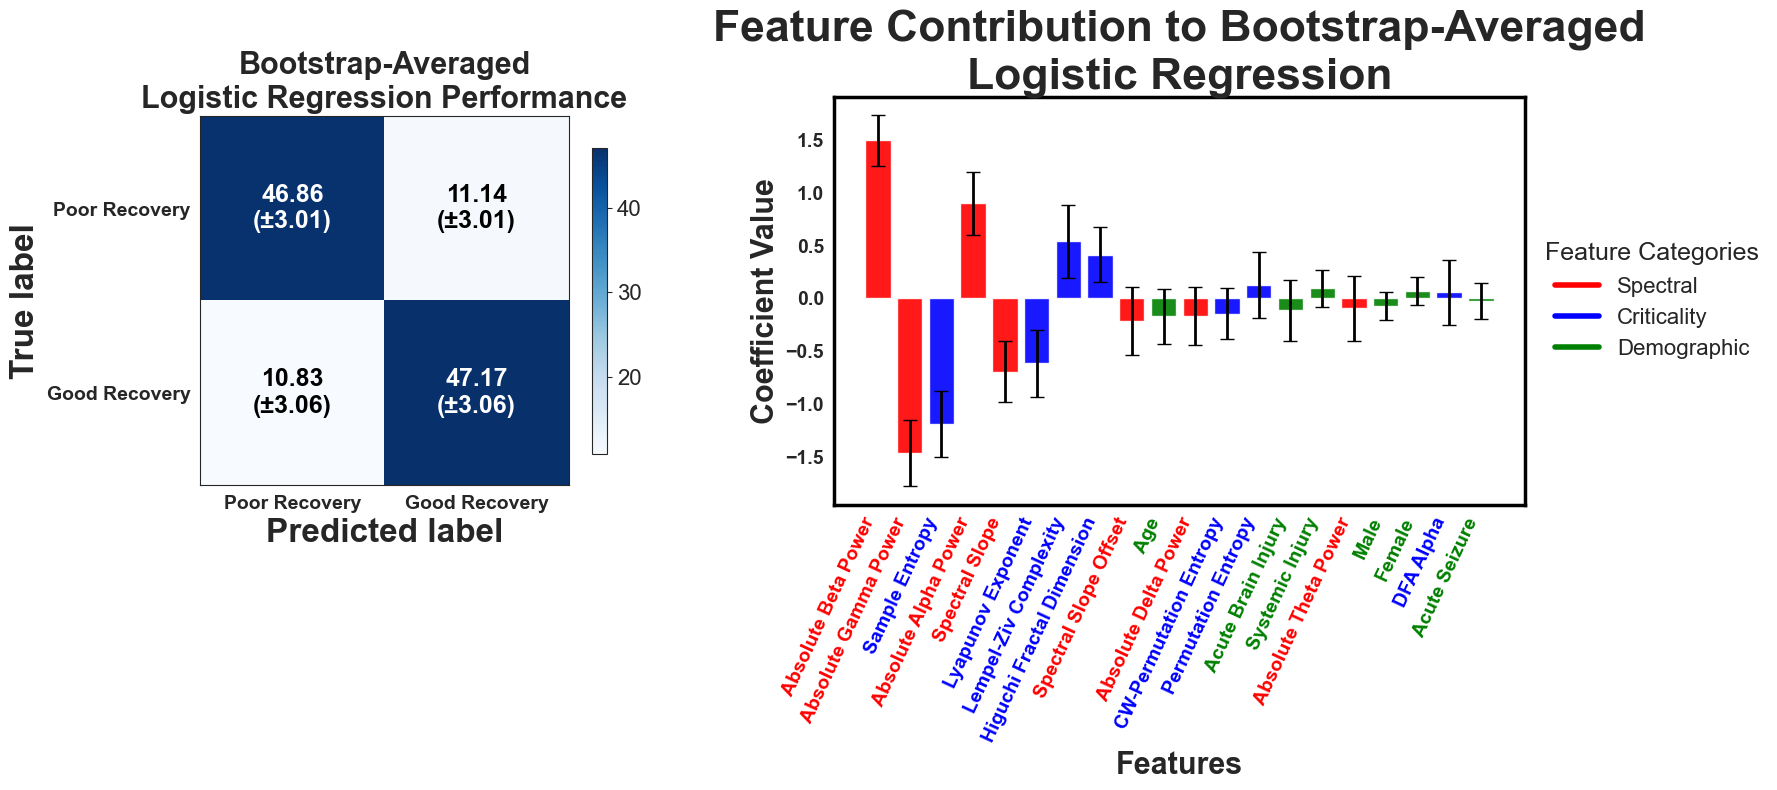

In [ ]:
sns.set_style('white')
# Define the confusion matrix plotting function
def plot_confusion_matrix(mean_cm, std_cm, classes, normalize=False, title='Confusion matrix', cmap=plt.cm.Blues):
    if normalize:
        mean_cm = mean_cm.astype('float') / mean_cm.sum(axis=1)[:, np.newaxis]
        std_cm = std_cm.astype('float') / mean_cm.sum(axis=1)[:, np.newaxis]
    else:
        print('Confusion matrix, without normalization')


    plt.imshow(mean_cm, interpolation='nearest', cmap=cmap)
    plt.title(title, fontsize=22, fontweight='bold')
    cbar = plt.colorbar(shrink=0.75)
    cbar.ax.tick_params(labelsize=16)  # Adjust the size as needed (e.g., 16)
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=0, fontsize=14, fontweight='bold')
    plt.yticks(tick_marks, classes, fontsize=14, fontweight='bold')

    fmt = '.2f'
    thresh = mean_cm.max() / 2.0
    for i, j in itertools.product(range(mean_cm.shape[0]), range(mean_cm.shape[1])):
        mean_value = format(mean_cm[i, j], fmt)
        std_value = format(std_cm[i, j], fmt)
        value_text = f"{mean_value}\n(±{std_value})"
        plt.text(j, i, value_text, horizontalalignment="center", verticalalignment="center",
                 color="white" if mean_cm[i, j] > thresh else "black", fontsize=18, fontweight='bold')

    plt.ylabel('True label', fontsize=24, fontweight='bold')
    plt.xlabel('Predicted label', fontsize=24, fontweight='bold')

# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8), gridspec_kw={'width_ratios': [1, 1.5]})

# --- Left Plot: Confusion Matrix ---
plt.sca(ax1)  # Set the current axis to ax1
plot_confusion_matrix(mean_cm, std_cm, classes=['Poor Recovery', 'Good Recovery'], 
                      title='Bootstrap-Averaged\nLogistic Regression Performance')

# --- Right Plot: Feature Importance ---
# Replace long feature names with multi-line versions
formatted_features = [feature.replace("Detrended Fluctuation Analysis Alpha", "DFA Alpha") 
                      for feature in sorted_features]

# Assign colors based on feature categories
bar_colors = []
for feature in sorted_features:
    feature_name = feature.replace("\n", " ")
    if feature_name in complexity_metrics:
        bar_colors.append(category_colors['Complexity'])
    elif feature_name in etiology_sex_age:
        bar_colors.append(category_colors['Etiology/Sex/Age'])
    elif feature_name in spectral_metrics:
        bar_colors.append(category_colors['Spectral'])
    else:
        bar_colors.append('gray')

# Plot on the second axis
plt.sca(ax2)  # Set the current axis to ax2
bars = ax2.bar(formatted_features, sorted_importance, yerr=sorted_std_coeffs, color=bar_colors,
               capsize=5, alpha=0.9, error_kw=dict(elinewidth=2, ecolor='black'))
ax2.set_xlabel('Features', fontsize=22, fontweight='bold')
ax2.set_ylabel('Coefficient Value', fontsize=22, fontweight='bold')
ax2.set_title('Feature Contribution to Bootstrap-Averaged\nLogistic Regression', fontsize=32, fontweight='bold')
ax2.tick_params(axis='x', rotation=65, labelsize=14, labelcolor='black')
ax2.tick_params(axis='y', labelsize=14)
plt.setp(ax2.get_xticklabels(), ha='right', fontweight='bold')
plt.setp(ax2.get_yticklabels(), fontweight='bold')

# Color x-tick labels based on bar_colors
for xtick, color in zip(ax2.get_xticklabels(), bar_colors):
    xtick.set_color(color)

# Customize spines
for spine in ax2.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(2.5)

# Create custom legend
legend_handles = [
    plt.Line2D([0], [0], color=category_colors['Spectral'], lw=4, label='Spectral'),
    plt.Line2D([0], [0], color=category_colors['Complexity'], lw=4, label='Criticality'),
    plt.Line2D([0], [0], color=category_colors['Etiology/Sex/Age'], lw=4, label='Demographic')
]
ax2.legend(handles=legend_handles, title="Feature Categories", fontsize=16, title_fontsize=18,
           loc="center left", bbox_to_anchor=(1.0, 0.5), frameon=False)

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(wspace=0.3, right=0.85)  # Adjust spacing between plots and right margin for legend

# Show the combined plot
plt.show()

Confusion matrix, without normalization


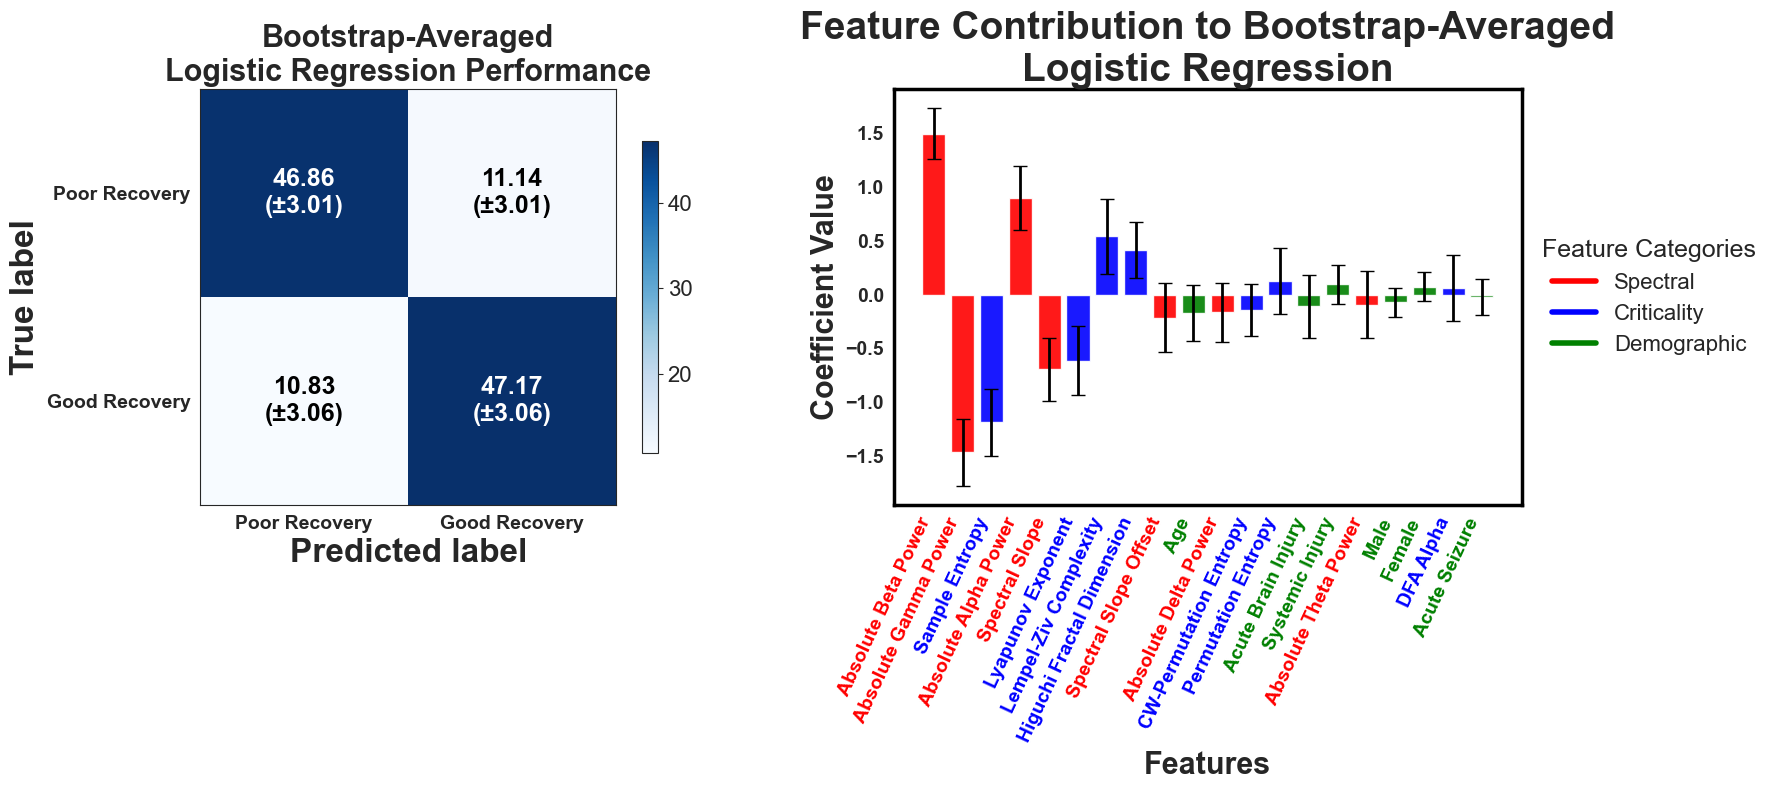

In [ ]:
sns.set_style('white')
# Define the confusion matrix plotting function
def plot_confusion_matrix(mean_cm, std_cm, classes, normalize=False, title='Confusion matrix', cmap=plt.cm.Blues):
    if normalize:
        mean_cm = mean_cm.astype('float') / mean_cm.sum(axis=1)[:, np.newaxis]
        std_cm = std_cm.astype('float') / mean_cm.sum(axis=1)[:, np.newaxis]
    else:
        print('Confusion matrix, without normalization')


    plt.imshow(mean_cm, interpolation='nearest', cmap=cmap)
    plt.title(title, fontsize=22, fontweight='bold')
    cbar = plt.colorbar(shrink=0.75)
    cbar.ax.tick_params(labelsize=16)  # Adjust the size as needed (e.g., 16)
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=0, fontsize=14, fontweight='bold')
    plt.yticks(tick_marks, classes, fontsize=14, fontweight='bold')

    fmt = '.2f'
    thresh = mean_cm.max() / 2.0
    for i, j in itertools.product(range(mean_cm.shape[0]), range(mean_cm.shape[1])):
        mean_value = format(mean_cm[i, j], fmt)
        std_value = format(std_cm[i, j], fmt)
        value_text = f"{mean_value}\n(±{std_value})"
        plt.text(j, i, value_text, horizontalalignment="center", verticalalignment="center",
                 color="white" if mean_cm[i, j] > thresh else "black", fontsize=18, fontweight='bold')

    plt.ylabel('True label', fontsize=24, fontweight='bold')
    plt.xlabel('Predicted label', fontsize=24, fontweight='bold')

# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8), gridspec_kw={'width_ratios': [1, 1.2]})

# --- Left Plot: Confusion Matrix ---
plt.sca(ax1)  # Set the current axis to ax1
plot_confusion_matrix(mean_cm, std_cm, classes=['Poor Recovery', 'Good Recovery'], 
                      title='Bootstrap-Averaged\nLogistic Regression Performance')

# --- Right Plot: Feature Importance ---
# Replace long feature names with multi-line versions
formatted_features = [feature.replace("Detrended Fluctuation Analysis Alpha", "DFA Alpha") 
                      for feature in sorted_features]

# Assign colors based on feature categories
bar_colors = []
for feature in sorted_features:
    feature_name = feature.replace("\n", " ")
    if feature_name in complexity_metrics:
        bar_colors.append(category_colors['Complexity'])
    elif feature_name in etiology_sex_age:
        bar_colors.append(category_colors['Etiology/Sex/Age'])
    elif feature_name in spectral_metrics:
        bar_colors.append(category_colors['Spectral'])
    else:
        bar_colors.append('gray')

# Plot on the second axis
plt.sca(ax2)  # Set the current axis to ax2
bars = ax2.bar(formatted_features, sorted_importance, yerr=sorted_std_coeffs, color=bar_colors,
               capsize=5, alpha=0.9, error_kw=dict(elinewidth=2, ecolor='black'))
ax2.set_xlabel('Features', fontsize=22, fontweight='bold')
ax2.set_ylabel('Coefficient Value', fontsize=22, fontweight='bold')
ax2.set_title('Feature Contribution to Bootstrap-Averaged\nLogistic Regression', fontsize=28, fontweight='bold')
ax2.tick_params(axis='x', rotation=65, labelsize=14, labelcolor='black')
ax2.tick_params(axis='y', labelsize=14)
plt.setp(ax2.get_xticklabels(), ha='right', fontweight='bold')
plt.setp(ax2.get_yticklabels(), fontweight='bold')

# Color x-tick labels based on bar_colors
for xtick, color in zip(ax2.get_xticklabels(), bar_colors):
    xtick.set_color(color)

# Customize spines
for spine in ax2.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(2.5)

# Create custom legend
legend_handles = [
    plt.Line2D([0], [0], color=category_colors['Spectral'], lw=4, label='Spectral'),
    plt.Line2D([0], [0], color=category_colors['Complexity'], lw=4, label='Criticality'),
    plt.Line2D([0], [0], color=category_colors['Etiology/Sex/Age'], lw=4, label='Demographic')
]
ax2.legend(handles=legend_handles, title="Feature Categories", fontsize=16, title_fontsize=18,
           loc="center left", bbox_to_anchor=(1.0, 0.5), frameon=False)

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(wspace=0.3, right=0.85)  # Adjust spacing between plots and right margin for legend

plt.savefig('/Users/derek/Documents/PICU/Manuscript_analysis/Manuscript Redo/Figures/tif_figures/combined_plot.tif', dpi=600, format='tif', bbox_inches='tight')
# Show the combined plot
plt.show()